### Merge the HRRR-AK NetCDF Files and Select Point Simulation Locations

Notebook contents 
* Merge the WY2020-WY2025 netcdf files created in `1_process` 
* And select the point locations for each site from this dataset 

created by Cassie Lumbrazo\
last updated: April 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [2]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray  # For CRS handling

In [3]:
pwd

'/home/cassie/python/repos/snow_modeling_point/icefield_domain'

## Load HRRR-AK UTM NetCDFs 

In [4]:
# Load the netCDF files for each water year
file_WY2020 = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_merged_grib_f567_WY2020_utm.nc'
file_WY2021 = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_merged_grib_f567_WY2021_utm.nc'
file_WY2022 = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_merged_grib_f567_WY2022_utm.nc'
file_WY2023 = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_merged_grib_f567_WY2023_utm.nc'
file_WY2024 = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_merged_grib_f567_WY2024_utm.nc'
file_WY2025 = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_merged_grib_f567_WY2025_utm.nc'

# Open the datasets
ds_WY2020 = xr.open_dataset(file_WY2020)
ds_WY2021 = xr.open_dataset(file_WY2021)
ds_WY2022 = xr.open_dataset(file_WY2022)
ds_WY2023 = xr.open_dataset(file_WY2023)
ds_WY2024 = xr.open_dataset(file_WY2024)
ds_WY2025 = xr.open_dataset(file_WY2025)

# Assign the same CRS to all datasets (assuming they are in the same UTM zone)
crs_utm = "EPSG:32608"  # Replace with the correct EPS
ds_WY2020.rio.write_crs(crs_utm, inplace=True)
ds_WY2021.rio.write_crs(crs_utm, inplace=True)
ds_WY2022.rio.write_crs(crs_utm, inplace=True)
ds_WY2023.rio.write_crs(crs_utm, inplace=True)
ds_WY2024.rio.write_crs(crs_utm, inplace=True)
ds_WY2025.rio.write_crs(crs_utm, inplace=True)

# Merge datasets along the time dimension
ds_merged = xr.concat([ds_WY2020, ds_WY2021, ds_WY2022, ds_WY2023, ds_WY2024, ds_WY2025], dim='time')

In [5]:
ds_merged

<xarray.Dataset> Size: 22GB
Dimensions:       (time: 52607, y: 59, x: 31)
Coordinates:
    valid_time    (time) datetime64[ns] 421kB 2019-10-01T05:00:00 ... 2025-10...
    step          (time) timedelta64[ns] 421kB 05:00:00 06:00:00 ... 07:00:00
  * time          (time) datetime64[ns] 421kB 2019-10-01T05:00:00 ... 2025-10...
  * y             (y) float64 472B 6.618e+06 6.615e+06 ... 6.449e+06 6.446e+06
  * x             (x) float64 248B 4.98e+05 5.009e+05 ... 5.842e+05 5.871e+05
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time, y, x) float64 770MB 11.4 8.462 5.587 ... nan nan nan
    pressure      (time, y, x) float64 770MB 8.952e+04 8.648e+04 ... nan nan
    orog          (time, y, x) float64 770MB 994.7 1.284e+03 ... nan nan
    temp_surface  (time, y, x) float64 770MB 278.6 277.5 278.0 ... nan nan nan
    swe           (time, y, x) float64 770MB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    snowdepth     (time, y, x) float64 770MB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    ...            ...
    suswrf        (time, y, x) float64 770MB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    sulwrf        (time, y, x) float64 770MB 324.3 319.7 321.5 ... nan nan nan
    wind          (time, y, x) float64 770MB 5.05 2.129 2.416 ... nan nan nan
    wind_dir      (time, y, x) float64 770MB 48.8 74.3 138.1 ... nan nan nan
    veg           (time, y, x) float64 770MB nan nan nan nan ... nan nan nan nan
    lai           (time, y, x) float64 770MB nan nan nan nan ... nan nan nan nan
Attributes:
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    level:           0
    typeOfLevel:     surface

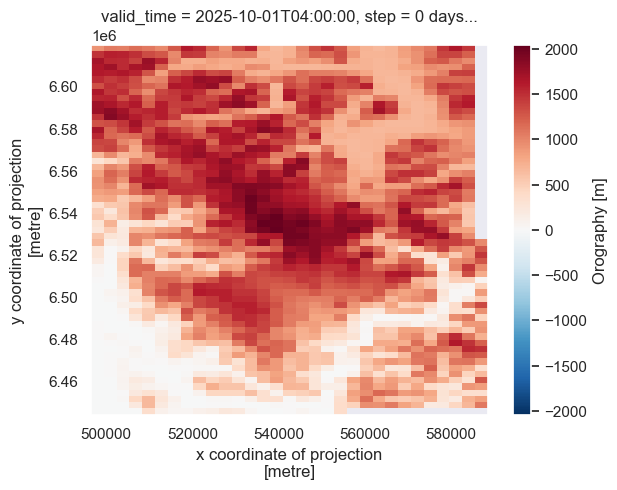

In [50]:
ds_merged.orog[-1].plot()

Text(0.5, 1.0, 'Temperature Timeseries for Grid Cell (x=0, y=0)')

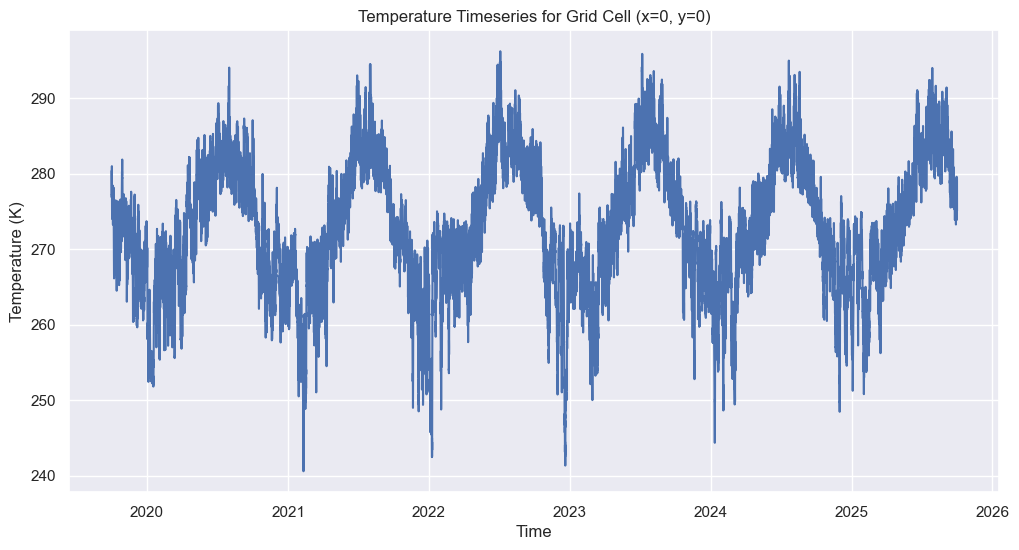

In [7]:
# make a plot for a single gridcell over time to check the timeseries look reasonable
# select a grid cell (e.g., the first one)
grid_cell = ds_merged.isel(x=0, y=0)  # Adjust
# Plot the timeseries for a variable (e.g., temperature)
plt.figure(figsize=(12, 6))
plt.plot(grid_cell['time'], grid_cell['temp'], label='Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature (K)')
plt.title('Temperature Timeseries for Grid Cell (x=0, y=0)')

In [8]:
# save the merged dataset to a new NetCDF file
output_merged_path = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm.nc'
ds_merged.to_netcdf(output_merged_path)
print(f"📁 Merged dataset saved to {output_merged_path}")

📁 Merged dataset saved to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm.nc


# Now, Select the Site Point Simulation Locations

### So, we are in UTM Zone 8N (EPSG:32608)
Now to get the lat/lon point locations for each site, 

we need to project the lat/lon for those locations (which are in WGS84) into EPSG:3268, and select the nearest gridcell

In [ ]:
# lat_ppsa, lon_ppsa = 58.26200, -134.51700
# lat_tram, lon_tram = 58.2971, -134.386
# lat_heen, lon_heen = 58.69652, -134.86448
# lat_tkg4, lon_tkg4 = 58.63447,-134.23708
# lat_mld4, lon_mld4 = 58.85892,-134.15728

In [10]:
# Path to the UTM NetCDF file
output_merged_path = '/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm.nc'

# Load the dataset
ds_utm = xr.open_dataset(output_merged_path)

# Assign CRS if not set
if ds_utm.rio.crs is None:
    ds_utm.rio.write_crs("EPSG:32608", inplace=True)

# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971,  "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.23708},
    "mld4": {"lat": 58.85892, "lon": -134.15728}
}

# Function to extract nearest grid cell for a site
def extract_site_data(ds, site_name, lat, lon):
    # Create GeoDataFrame for the site
    gdf_site = gpd.GeoDataFrame({
        "site": [site_name],
        "geometry": [Point(lon, lat)]
    }, crs="EPSG:4326")
    
    # Convert to UTM (same as dataset)
    gdf_site_proj = gdf_site.to_crs("EPSG:32608")
    x_site, y_site = gdf_site_proj.geometry[0].x, gdf_site_proj.geometry[0].y
    
    # Select nearest grid cell
    ds_site = ds.sel(x=x_site, y=y_site, method="nearest")
    
    # Add site info as attributes
    ds_site.attrs.update({
        "site_name": site_name,
        "original_lat": lat,
        "original_lon": lon,
        "utm_x": x_site,
        "utm_y": y_site
    })
    
    return ds_site

# Process each site
for site_name, coords in sites.items():
    ds_site = extract_site_data(ds_utm, site_name, coords["lat"], coords["lon"])
    
    # Save to NetCDF
    output_path = f"/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_{site_name}.nc"
    ds_site.to_netcdf(output_path)
    print(f"📁 Saved site data for {site_name} to {output_path}")

print("✅ All site extractions completed!")

📁 Saved site data for ppsa to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc
📁 Saved site data for tram to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc
📁 Saved site data for heen to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc
📁 Saved site data for tkg4 to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc
📁 Saved site data for mld4 to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc
✅ All site extractions completed!


# Plot the Sites

### First, as a map

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Text(0.5, 1.0, 'HRRR temp (single timestep) with site locations')

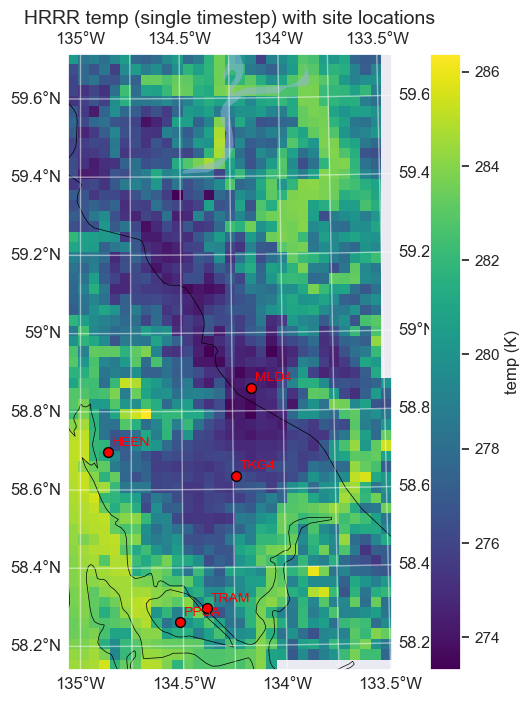

In [13]:
# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.23708},
    "mld4": {"lat": 58.85892, "lon": -134.15728}
}

# Create GeoDataFrame for sites
gdf_sites = gpd.GeoDataFrame({
    "site": list(sites.keys()),
    "geometry": [Point(sites[site]["lon"], sites[site]["lat"]) for site in sites]
}, crs="EPSG:4326")

# Convert sites to UTM (same as dataset)
gdf_sites_utm = gdf_sites.to_crs("EPSG:32608")

# Select a variable for background (e.g., temp at first time step)
var_name = 'temp'  # Change to any variable, e.g., 'temp', 'precip_total'
background_data = ds_utm[var_name].isel(time=0)  # First time step

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(8)})  # UTM Zone 8N

# Plot the background raster
background_data.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'label': f'{var_name} ({background_data.attrs.get("units", "")})'})

# Add coastlines and features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, alpha=0.5)

# Plot site points
for idx, row in gdf_sites_utm.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    ax.text(x + 1000, y + 1000, row['site'].upper(), fontsize=10, color='red', ha='left', va='bottom', zorder=6)

# Set title
ax.set_title(f"HRRR {var_name} (single timestep) with site locations", fontsize=14)

# # Save or show the plot
# plt.tight_layout()
# plt.savefig("/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_temp_sites_map.png", dpi=300)
# plt.show()

# print("✅ Map plotted and saved!")

Text(0.5, 1.0, 'HRRR orog (single timestep) with site locations')

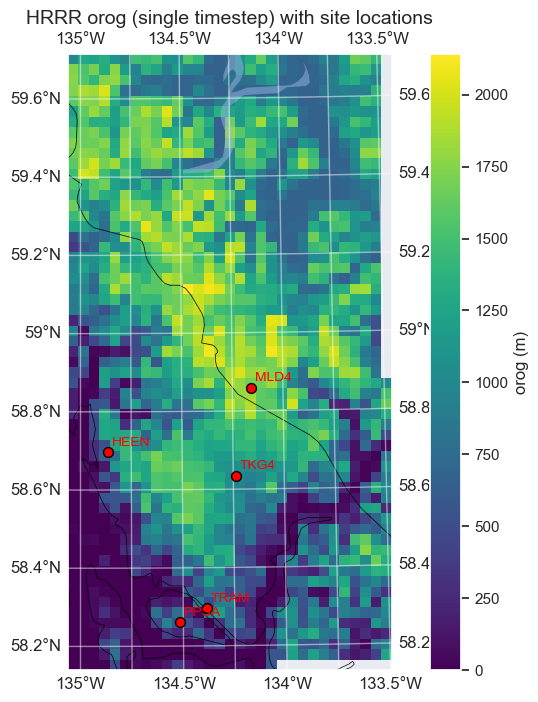

In [51]:
# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.23708},
    "mld4": {"lat": 58.85892, "lon": -134.15728}
}

# Create GeoDataFrame for sites
gdf_sites = gpd.GeoDataFrame({
    "site": list(sites.keys()),
    "geometry": [Point(sites[site]["lon"], sites[site]["lat"]) for site in sites]
}, crs="EPSG:4326")

# Convert sites to UTM (same as dataset)
gdf_sites_utm = gdf_sites.to_crs("EPSG:32608")

# Select a variable for background (e.g., temp at first time step)
var_name = 'orog'  # Change to any variable, e.g., 'temp', 'precip_total'
background_data = ds_utm[var_name].isel(time=0)  # First time step

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(8)})  # UTM Zone 8N

# Plot the background raster
background_data.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'label': f'{var_name} ({background_data.attrs.get("units", "")})'})

# Add coastlines and features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, alpha=0.5)

# Plot site points
for idx, row in gdf_sites_utm.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    ax.text(x + 1000, y + 1000, row['site'].upper(), fontsize=10, color='red', ha='left', va='bottom', zorder=6)

# Set title
ax.set_title(f"HRRR {var_name} (single timestep) with site locations", fontsize=14)

# # Save or show the plot
# plt.tight_layout()
# plt.savefig("/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_temp_sites_map.png", dpi=300)
# plt.show()

# print("✅ Map plotted and saved!")

### Plot Timeseries to Compare

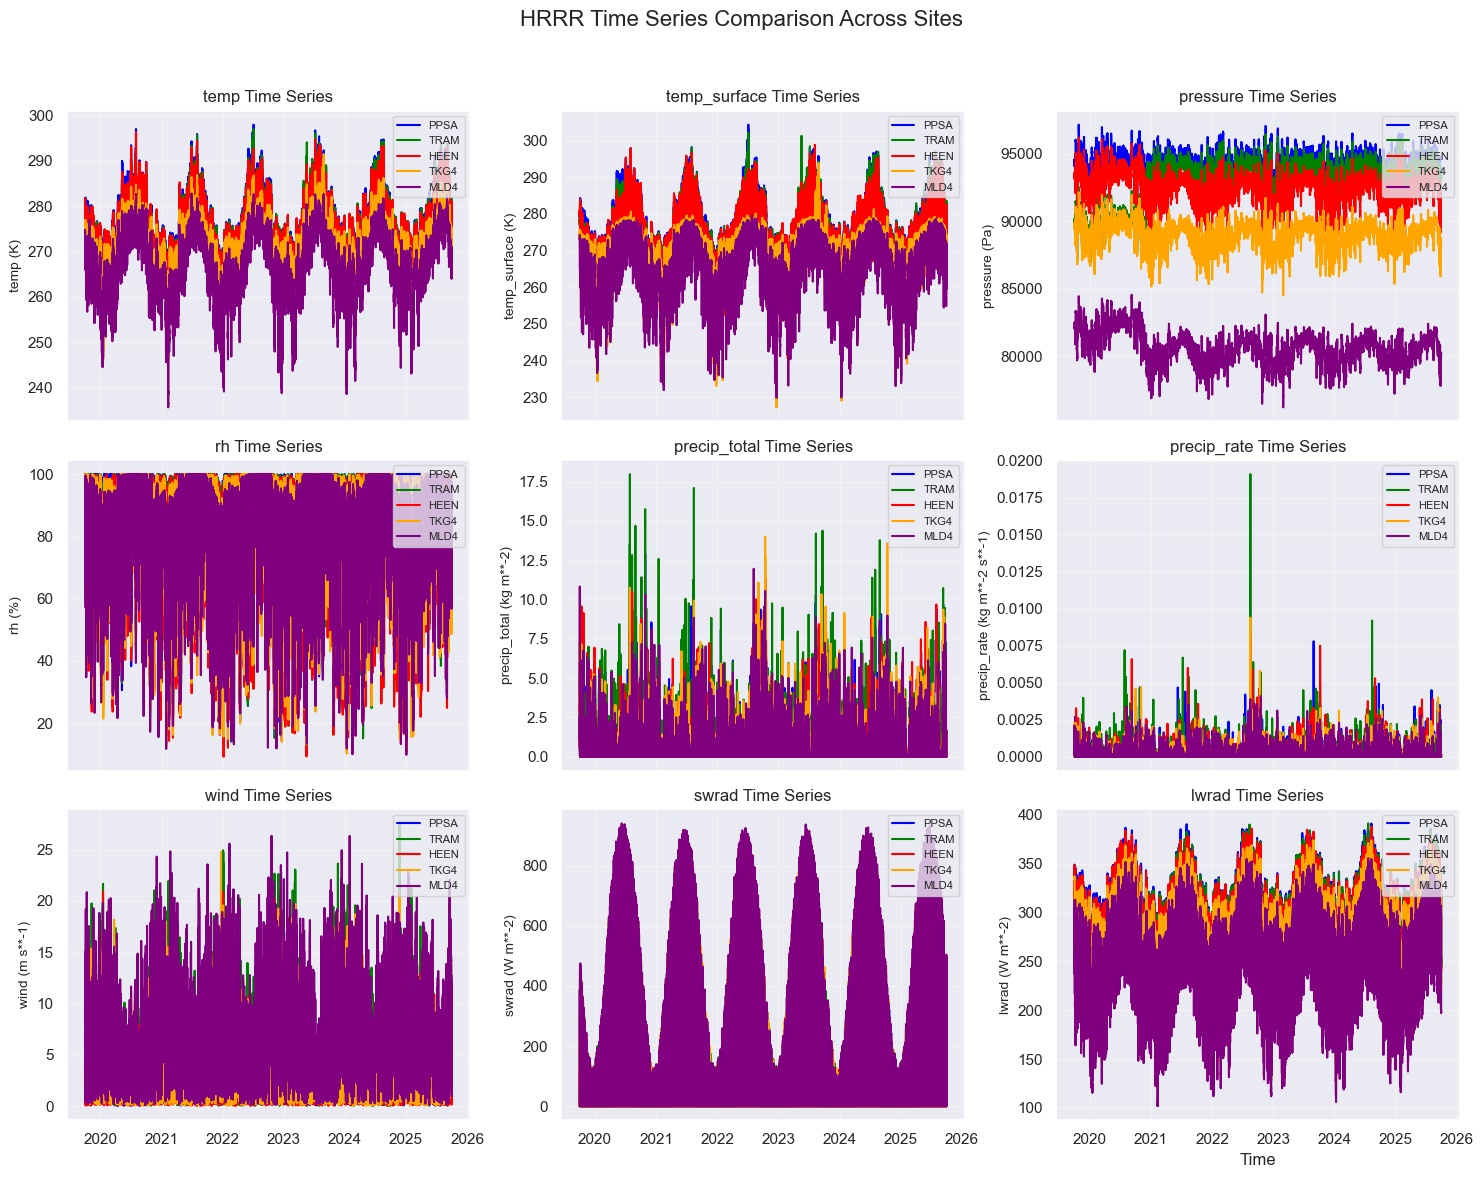

In [15]:
# Paths to site NetCDFs (assuming they were saved as per previous code)
site_files = {
    "ppsa": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc",
    "tram": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc",
    "heen": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc",
    "tkg4": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc",
    "mld4": "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc"
}

# Load datasets
site_ds = {}
for site, path in site_files.items():
    ds = xr.open_dataset(path)
    site_ds[site] = ds

# Variables to plot (important for modeling)
variables = ['temp', 'temp_surface', 'pressure', 'rh', 'precip_total', 'precip_rate', 'wind', 'swrad', 'lwrad']

# Colors for sites
colors = {'ppsa': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange', 'mld4': 'purple'}

# Create subplots (3x3 grid for 9 variables)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
axes = axes.flatten()  # Flatten for easy indexing

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            # Convert to pandas for easier plotting (if needed)
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=12)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Set common x-label
axes[-1].set_xlabel("Time", fontsize=12)  # Bottom-right subplot

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# # Save the plot
# output_plot = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_sites_timeseries_comparison.png"
# plt.savefig(output_plot, dpi=300)

plt.show()

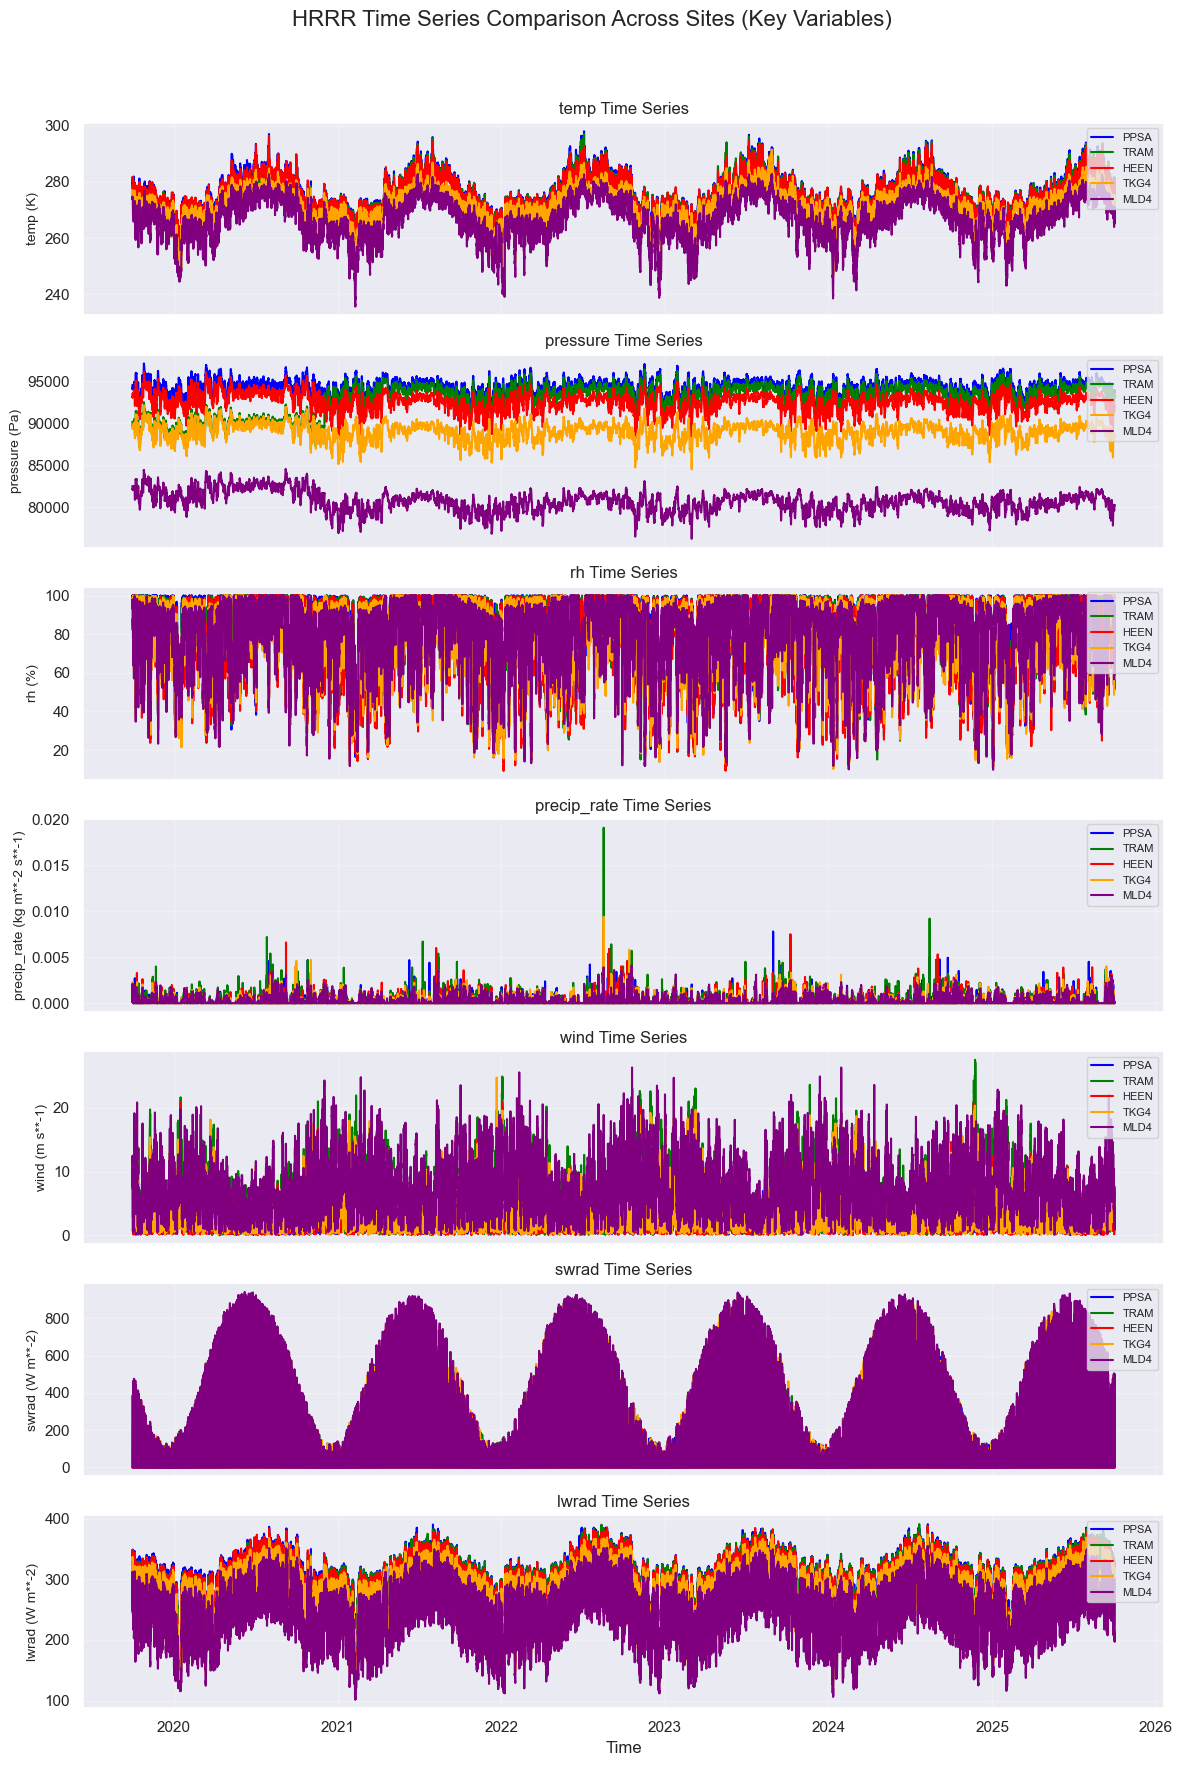

In [16]:
# Variables to plot (subset for modeling)
variables = ['temp', 'pressure', 'rh', 'precip_rate', 'wind', 'swrad', 'lwrad']

# Colors for sites
colors = {'ppsa': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange', 'mld4': 'purple'}

# Create subplots (7 rows, 1 column for wider plots)
fig, axes = plt.subplots(7, 1, figsize=(12, 18), sharex=True)  # Wider and taller

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=12)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Set common x-label on the last subplot
axes[-1].set_xlabel("Time", fontsize=12)

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites (Key Variables)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

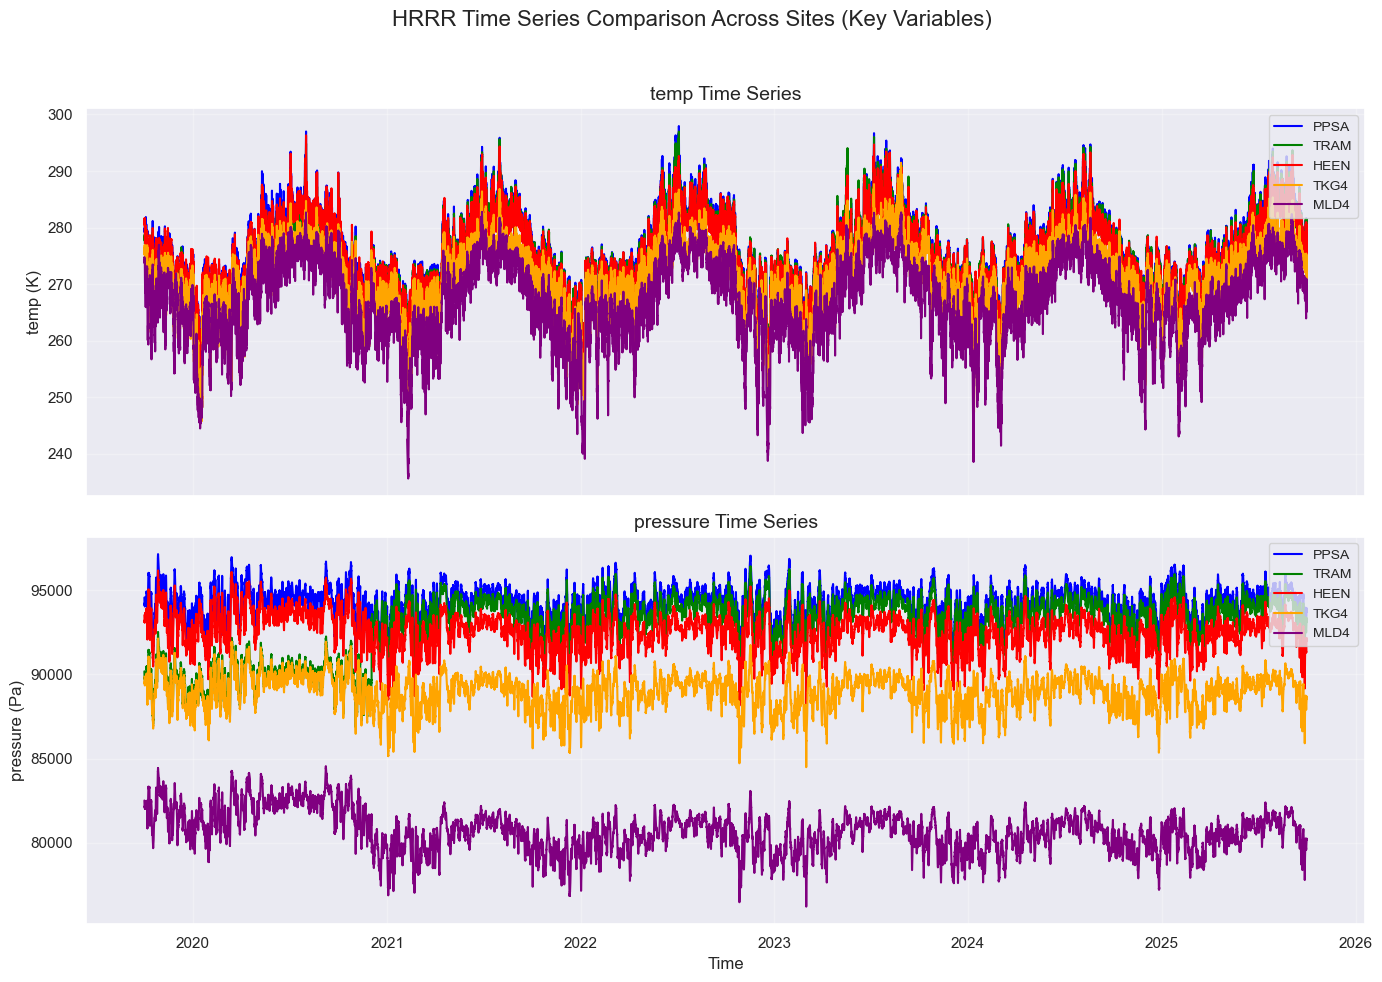

In [53]:
# Variables to plot (subset for modeling)
variables = ['temp', 'pressure']

# Colors for sites
colors = {'ppsa': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange', 'mld4': 'purple'}

# Create subplots (2 rows, 1 column for wider plots)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)  # Wider and taller

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=14)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

# Set common x-label on the last subplot
axes[-1].set_xlabel("Time", fontsize=12)

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites (Key Variables)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Finally, print the elevation of of each gridcell to compare 

In [23]:
# compare the gridcell elevation for each site to the field elevation

# ppsa to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc
# tram to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc
# heen to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc
# tkg4 to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc
# mld4 to /hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc

ppsa_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc")
tram_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc")
heen_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc")
tkg4_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tkg4.nc")
mld4_ds = xr.open_dataset("/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_mld4.nc")

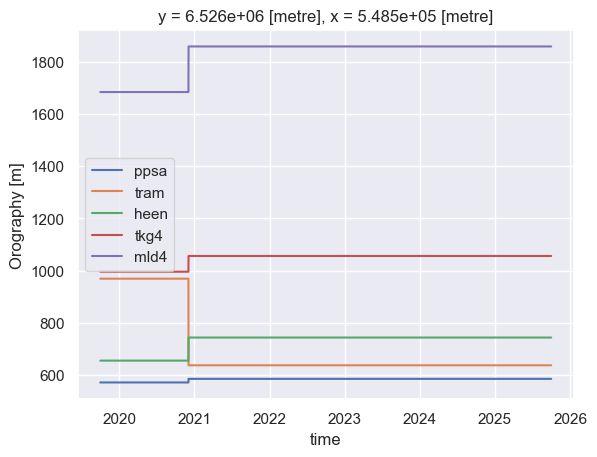

In [37]:
ppsa_ds['orog'].plot()
tram_ds['orog'].plot()
heen_ds['orog'].plot()
tkg4_ds['orog'].plot()
mld4_ds['orog'].plot()

plt.legend(['ppsa', 'tram', 'heen', 'tkg4', 'mld4'])

In [40]:
# print the last elevation of each netcdf
ppsa_ds['orog'][-1].values

# save the last orog value for each site into a df with columns site and elevation_m
df_elevation = pd.DataFrame({
    'site': ['ppsa', 'tram', 'heen', 'tkg4', 'mld4'],
    'hrrrak_elevation_m': [ppsa_ds['orog'][-1].values, tram_ds['orog'][-1].values, heen_ds['orog'][-1].values, tkg4_ds['orog'][-1].values, mld4_ds['orog'][-1].values],
    'real_elevation_m': [669.9, 529.1, 548.0, 1120, 1900]
})
df_elevation

,site,hrrrak_elevation_m,real_elevation_m
0,ppsa,585.550986841321,669.9
1,tram,637.394736841321,529.1
2,heen,743.613486841321,548.0
3,tkg4,1055.800986841321,1120.0
4,mld4,1857.707236841321,1900.0


In [41]:
df_elevation['diff'] = df_elevation['hrrrak_elevation_m'] - df_elevation['real_elevation_m']
df_elevation

,site,hrrrak_elevation_m,real_elevation_m,diff
0,ppsa,585.550986841321,669.9,-84.349013
1,tram,637.394736841321,529.1,108.294737
2,heen,743.613486841321,548.0,195.613487
3,tkg4,1055.800986841321,1120.0,-64.199013
4,mld4,1857.707236841321,1900.0,-42.292763


/tmp/ipykernel_2994083/4107987374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='site', y='diff', data=df_elevation, palette='viridis')


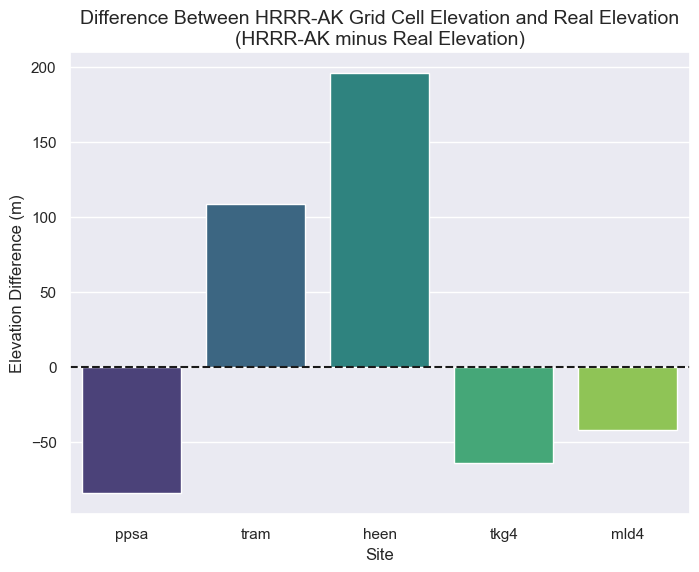

In [48]:
# make a box plot to visualize the elevation differences
plt.figure(figsize=(8, 6))
sns.barplot(x='site', y='diff', data=df_elevation, palette='viridis')
plt.axhline(0, color='k', linestyle='--')
plt.title('Difference Between HRRR-AK Grid Cell Elevation and Real Elevation\n(HRRR-AK minus Real Elevation)', fontsize=14)
plt.ylabel('Elevation Difference (m)', fontsize=12)
plt.xlabel('Site', fontsize=12)
plt.show()

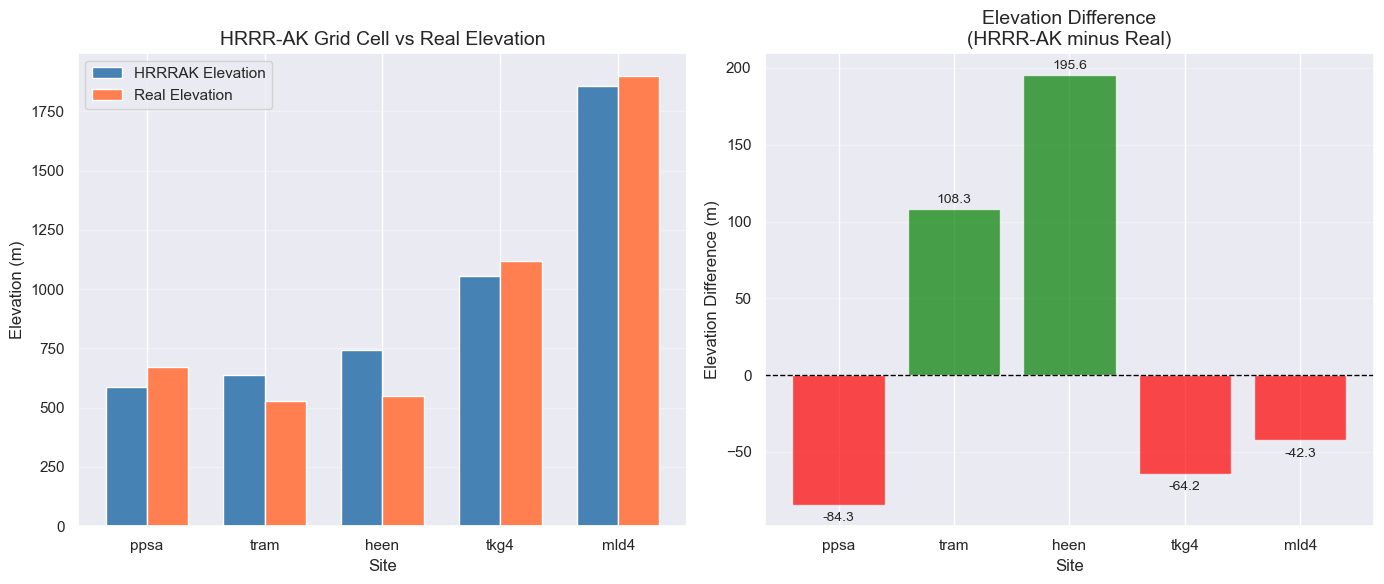

In [47]:
# make a similar plot except with all three bars for each site (hrrrak elevation, real elevation, and difference)
# Using subplots to handle the different scales properly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: HRRRAK vs Real elevation
x = np.arange(len(df_elevation['site']))
width = 0.35

bars1 = ax1.bar(x - width/2, df_elevation['hrrrak_elevation_m'], width, label='HRRRAK Elevation', color='steelblue')
bars2 = ax1.bar(x + width/2, df_elevation['real_elevation_m'], width, label='Real Elevation', color='coral')

ax1.set_xlabel('Site', fontsize=12)
ax1.set_ylabel('Elevation (m)', fontsize=12)
ax1.set_title('HRRR-AK Grid Cell vs Real Elevation', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(df_elevation['site'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right plot: Difference elevation
colors = ['green' if x >= 0 else 'red' for x in df_elevation['diff']]
ax2.bar(df_elevation['site'], df_elevation['diff'], color=colors, alpha=0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Site', fontsize=12)
ax2.set_ylabel('Elevation Difference (m)', fontsize=12)
ax2.set_title('Elevation Difference\n(HRRR-AK minus Real)', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on the diff bars
for i, v in enumerate(df_elevation['diff']):
    ax2.text(i, v + (2 if v >= 0 else -5), f'{v:.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()